In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

Downloading the dataset

In [ ]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)


test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

In [ ]:
train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

In [ ]:
learning_rate = 1e-3
batch_size = 64
epochs = 10

In [ ]:
# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    return total_loss / len(dataloader)


def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss

In [ ]:
epochs = 10
train_losses = []
val_losses = []
best_val_loss = float("inf")

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    avg_train_loss = train_loop(train_dataloader, model, loss_fn, optimizer)
    avg_val_loss = test_loop(test_dataloader, model, loss_fn)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Saved new best model (val loss {best_val_loss:.4f})")
print("Done!")

Epoch 1
-------------------------------
loss: 2.303000  [   64/60000]
loss: 0.558576  [ 6464/60000]
loss: 0.370651  [12864/60000]
loss: 0.510377  [19264/60000]
loss: 0.442801  [25664/60000]
loss: 0.434106  [32064/60000]
loss: 0.361209  [38464/60000]
loss: 0.523958  [44864/60000]
loss: 0.475318  [51264/60000]
loss: 0.510858  [57664/60000]
Test Error: 
 Accuracy: 84.2%, Avg loss: 0.426104 

Saved new best model (val loss 0.4261)
Epoch 2
-------------------------------
loss: 0.271386  [   64/60000]
loss: 0.353280  [ 6464/60000]
loss: 0.265990  [12864/60000]
loss: 0.393148  [19264/60000]
loss: 0.394727  [25664/60000]
loss: 0.372332  [32064/60000]
loss: 0.311073  [38464/60000]
loss: 0.480839  [44864/60000]
loss: 0.413163  [51264/60000]
loss: 0.439891  [57664/60000]
Test Error: 
 Accuracy: 85.7%, Avg loss: 0.385073 

Saved new best model (val loss 0.3851)
Epoch 3
-------------------------------
loss: 0.219942  [   64/60000]
loss: 0.327670  [ 6464/60000]
loss: 0.232464  [12864/60000]
loss: 0.

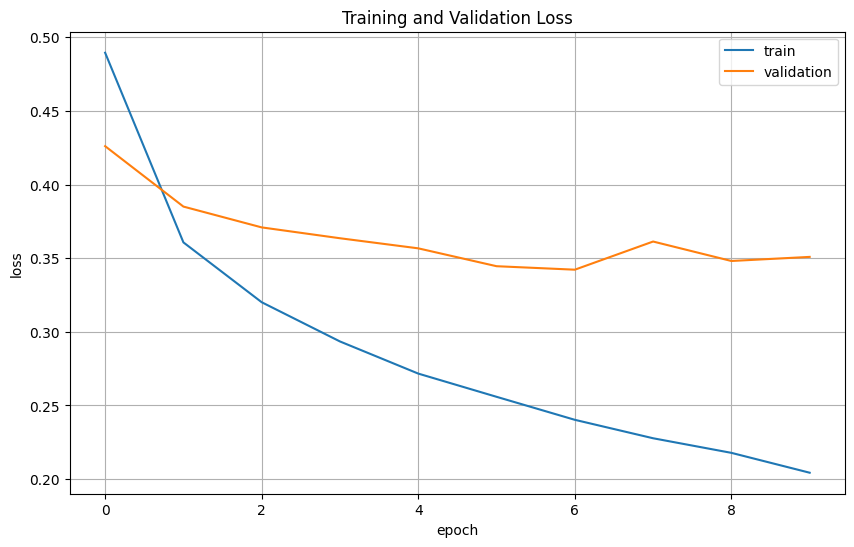

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

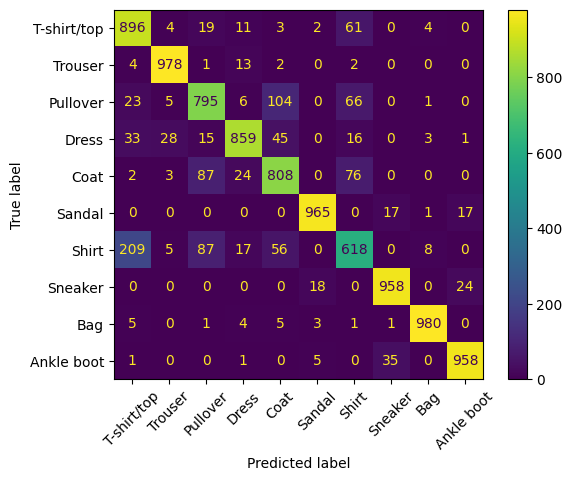

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import torch

# Collect all predictions and true labels from the test loader
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X, y in test_dataloader:
        pred = model(X)
        all_preds.extend(pred.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_preds,
    display_labels=test_data.classes,
    xticks_rotation=45
)
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=test_data.classes))

              precision    recall  f1-score   support

 T-shirt/top       0.76      0.90      0.82      1000
     Trouser       0.96      0.98      0.97      1000
    Pullover       0.79      0.80      0.79      1000
       Dress       0.92      0.86      0.89      1000
        Coat       0.79      0.81      0.80      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.74      0.62      0.67      1000
     Sneaker       0.95      0.96      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

